# Advanced Exploration Strategies

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the exploration-exploitation trade-off beyond ε-greedy
- Implement Boltzmann (softmax) action selection and Thompson sampling
- Set both against ε-greedy and UCB on the same bandit and FrozenLake runs
- Tune exploration for sample efficiency

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 03 "Bayesian Inference in ML" — Thompson sampling keeps a posterior over each action's value and updates it with every observed reward, so the prior → likelihood → posterior loop from that lesson becomes an exploration rule you can run.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 4**.

---


## Lesson Brief

This lesson focuses on how exploration should be balanced, not just turned on or off.

Students will see why too little exploration traps the agent early, while too much exploration slows useful learning.

Why this matters: good RL systems need a balance that changes over time.

This notebook helps students reason about that balance explicitly.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: a 1933 idea about clinical trials that beat the 2010s state of the art

Thompson sampling is not a modern trick. William R. Thompson published it in *Biometrika* in **1933**,
and his motivating problem was a medical one: when two treatments are being compared, how should
patients be allocated, given that every patient assigned to the worse treatment is a person you
harmed in order to learn something? His answer is the one the code below implements — maintain a
belief about each option, draw a sample from that belief, and act on the sample. Options you are
uncertain about get drawn optimistically often; options you have ruled out get drawn rarely.

The idea then sat largely unused for seventy years, because nobody had shown it worked in practice.
Chapelle and Li closed that gap with "An Empirical Evaluation of Thompson Sampling" (NIPS 2011),
testing it on simulated and real display-advertising and news-recommendation data and finding it
competitive with — often better than — the UCB methods that had the theory behind them. That paper is
why Thompson sampling is now a default in production recommendation and advertising systems, and why
it is in this notebook.

**What goes wrong without this.** ε-greedy explores *uniformly*: when it decides to explore, an arm
it has sampled 400 times and knows is bad is as likely to be picked as one it has barely tried.
Thompson sampling explores *in proportion to uncertainty*. Watch that difference appear in the
posterior means below — and note that the arm with the true payoff of 0.55 ends with the highest
posterior, while the two losing arms end with far fewer pulls behind their estimates.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Helps students understand the balancing act before focusing on a single heuristic.
- Best when they need the big-picture reasoning behind exploration choices.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


## Real-World Context

These strategies are what online systems use when every choice costs something real: which article or ad to show next, which variant an A/B test should send more traffic to, which treatment arm to keep open. The bandit code below is that same machinery at classroom scale.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Install or import dependencies so later cells can run.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Pip progress lines and usually a confirmation that imports work.

**If you feel lost:** Fix any red install error before continuing—later cells assume this cell succeeded.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install numpy matplotlib scipy -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
from scipy.stats import beta
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Thompson Sampling


### Step Guide

**What this cell does:** Follow the printed section: "Estimated arm preferences (alpha / (alpha+beta)):"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `ThompsonSampling` (what it does): Thompson Sampling for a Bernoulli multi-armed bandit (Beta priors).
class ThompsonSampling:
    """Thompson Sampling for a Bernoulli multi-armed bandit (Beta priors)."""

    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, n_arms.
    def __init__(self, n_arms: int):
        # Save a value in a name so the next lines can read it.
        self.n_arms = n_arms
        # Beta(1,1) prior per arm
        # Save a value in a name so the next lines can read it.
        self.alpha = np.ones(n_arms)
        # Another assignment—same idea: store a value for the lines below.
        self.beta = np.ones(n_arms)

    # Function `select_arm` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def select_arm(self) -> int:
        # Save a value in a name so the next lines can read it.
        samples = [np.random.beta(self.alpha[i], self.beta[i]) for i in range(self.n_arms)]
        # Send a value back to whoever called this function.
        return int(np.argmax(samples))

    # Function `update` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, arm, reward.
    def update(self, arm: int, reward: float):
        # Rewards here are binary: 1.0 means success and 0.0 means failure.
        # If the condition is True, run the indented block under this line.
        if reward == 1.0:
            # Save a value in a name so the next lines can read it.
            self.alpha[arm] += 1
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            self.beta[arm] += 1


# Demo: 3 arms with hidden Bernoulli success rates (independent per arm; they do not need to sum to 1).
# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
arm_success_rates = np.array([0.35, 0.55, 0.40])
# Another assignment—same idea: store a value for the lines below.
ts = ThompsonSampling(len(arm_success_rates))
# Another assignment—same idea: store a value for the lines below.
pulls = 500
# Start a loop: repeat the indented block once per item in the sequence.
for t in range(pulls):
    # Save a value in a name so the next lines can read it.
    arm = ts.select_arm()
    # Another assignment—same idea: store a value for the lines below.
    r = 1.0 if np.random.rand() < arm_success_rates[arm] else 0.0
    # Execute: ts.update(arm, r)
    ts.update(arm, r)
# Show text or numbers in the cell output area under the code.
print("Estimated arm preferences (alpha / (alpha+beta)):")
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(len(arm_success_rates)):
    # Show text or numbers in the cell output area under the code.
    print(f"  Arm {i}: true p={arm_success_rates[i]:.2f}  posterior mean={ts.alpha[i]/(ts.alpha[i]+ts.beta[i]):.3f}")


Estimated arm preferences (alpha / (alpha+beta)):
  Arm 0: true p=0.35  posterior mean=0.409
  Arm 1: true p=0.55  posterior mean=0.540
  Arm 2: true p=0.40  posterior mean=0.278


## Part 2: A/B Testing Application


### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Simulate A/B testing as a two-armed bandit (page A vs page B conversion)
# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(0)
# Save a value in a name so the next lines can read it.
conv_a, conv_b = 0.08, 0.11  # true conversion rates (B is better)
# Another assignment—same idea: store a value for the lines below.
ts_ab = ThompsonSampling(2)
# Another assignment—same idea: store a value for the lines below.
trials = 2000
# Start a loop: repeat the indented block once per item in the sequence.
for _ in range(trials):
    # Save a value in a name so the next lines can read it.
    arm = ts_ab.select_arm()
    # Another assignment—same idea: store a value for the lines below.
    p = conv_a if arm == 0 else conv_b
    # Unpack the one-step model output from transition(state, action).
    reward = 1.0 if np.random.rand() < p else 0.0
    # Execute: ts_ab.update(arm, reward)
    ts_ab.update(arm, reward)

# Show text or numbers in the cell output area under the code.
print("A/B test (Thompson Sampling) after", trials, "visitors:")
# Show text or numbers in the cell output area under the code.
print(f"  Arm A (design A) posterior mean: {ts_ab.alpha[0]/(ts_ab.alpha[0]+ts_ab.beta[0]):.3f}  (true {conv_a})")
# Show text or numbers in the cell output area under the code.
print(f"  Arm B (design B) posterior mean: {ts_ab.alpha[1]/(ts_ab.alpha[1]+ts_ab.beta[1]):.3f}  (true {conv_b})")
# Show text or numbers in the cell output area under the code.
print("  → Higher posterior mean ≈ model believes that variant converts better.")


A/B test (Thompson Sampling) after 2000 visitors:
  Arm A (design A) posterior mean: 0.089  (true 0.08)
  Arm B (design B) posterior mean: 0.113  (true 0.11)
  → Higher posterior mean ≈ model believes that variant converts better.


## Part 3: Boltzmann (Softmax) Exploration

ε-greedy explores blindly: with probability ε it picks **any** action, even one it already knows is terrible. **Boltzmann exploration** (also called softmax exploration) is smarter about *which* wrong actions it tries: it turns the current value estimates into a probability distribution,

$$P(a) = \frac{e^{Q(a)/\tau}}{\sum_b e^{Q(b)/\tau}}$$

so better-looking actions are tried more often, and clearly bad ones only rarely.

The **temperature** τ (tau) controls the balance:

- **high τ** → probabilities flatten toward uniform → lots of exploration
- **low τ** → probabilities concentrate on the argmax → nearly greedy
- **τ → 0** recovers pure exploitation

**Decay connection:** just as ε is often *decayed* over time (Unit 1, lesson 05), τ can be started high and cooled down — explore early, exploit late. The next cell shows both effects with real numbers.

### Step Guide

**What this cell does:** Computes **softmax action probabilities** for one fixed set of Q-estimates at several temperatures, then runs two short Boltzmann bandit simulations (hot τ vs cool τ) and prints their measured totals.

**How to read it (weak Python OK):** The probability table is the heart: same Q-values, different τ, very different behaviour. The simulation just confirms the table's prediction with rewards.

**What to expect in the output:** One probability row per τ, then total rewards for the hot and cool runs with a conclusion computed from those totals.

**If you feel lost:** Read one row of the table: at τ=0.05 nearly all probability sits on the best-looking arm; at τ=5 the three arms are almost equally likely.

In [4]:
# Part 3: Boltzmann (softmax) exploration — same Q-estimates, different temperatures.
# First we LOOK at the probabilities the formula produces, then we let them act in a bandit.

# Fixed example Q-estimates for a 3-armed bandit (arm 1 currently looks best).
q_estimates = np.array([0.20, 0.50, 0.30])


def boltzmann_probs(q, tau):
    """Softmax with temperature: subtract the max first for numerical stability."""
    scaled = (q - q.max()) / tau
    e = np.exp(scaled)
    return e / e.sum()


# Probability table: one row per temperature, same value estimates every time.
print("Boltzmann action probabilities for Q =", q_estimates.tolist())
print("\n  tau  |  P(arm 0)  P(arm 1)  P(arm 2)")
for tau in (0.05, 0.2, 1.0, 5.0):
    p = boltzmann_probs(q_estimates, tau)
    print(f"  {tau:4} |   {p[0]:.3f}     {p[1]:.3f}     {p[2]:.3f}")
print("\nLow tau -> nearly greedy; high tau -> nearly uniform. Same Q, different behaviour.")

# Now let the rule act: two short bandit runs with a hot vs a cool temperature.
rng = np.random.default_rng(3)
TRUE_P = [0.35, 0.55, 0.40]   # true (hidden) success rate per arm


def run_boltzmann(tau, rounds=400):
    """Boltzmann bandit: sample the arm from softmax(Q/tau), update running means."""
    counts, totals = np.zeros(3), np.zeros(3)
    reward_sum = 0
    for _ in range(rounds):
        # Current value estimates (running mean per arm; unvisited arms count as 0).
        q = totals / np.maximum(counts, 1)
        # Draw the arm from the softmax distribution instead of argmax-or-random.
        arm = rng.choice(3, p=boltzmann_probs(q, tau))
        r = 1.0 if rng.random() < TRUE_P[arm] else 0.0
        counts[arm] += 1
        totals[arm] += r
        reward_sum += r
    return reward_sum


hot_total = run_boltzmann(tau=5.0)
cool_total = run_boltzmann(tau=0.2)
print(f"\nMeasured over 400 rounds — hot tau=5.0: {hot_total:.0f} total reward,"
      f" cool tau=0.2: {cool_total:.0f} total reward")
# Conclusion phrased from the measured totals, not assumed in advance.
# A handful of reward points over 400 noisy rounds is a tie, not a victory.
if abs(cool_total - hot_total) <= 10:
    print("In this run the two temperatures ended essentially tied — 400 rounds of a")
    print("noisy bandit cannot separate them; the probability table above is the real lesson.")
elif cool_total > hot_total:
    print("In this run the cooler temperature won: it exploited the best arm once found.")
else:
    print("In this run the hotter temperature won — with few rounds, extra exploration can pay.")
print("Practical recipe: start with a higher tau (explore), cool it over time (exploit) —")
print("the same idea as the epsilon-decay schedule from Unit 1, lesson 05.")


Boltzmann action probabilities for Q = [0.2, 0.5, 0.3]

  tau  |  P(arm 0)  P(arm 1)  P(arm 2)
  0.05 |   0.002     0.980     0.018
   0.2 |   0.140     0.629     0.231
   1.0 |   0.289     0.391     0.320
   5.0 |   0.324     0.345     0.331

Low tau -> nearly greedy; high tau -> nearly uniform. Same Q, different behaviour.

Measured over 400 rounds — hot tau=5.0: 180 total reward, cool tau=0.2: 181 total reward
In this run the two temperatures ended essentially tied — 400 rounds of a
noisy bandit cannot separate them; the probability table above is the real lesson.
Practical recipe: start with a higher tau (explore), cool it over time (exploit) —
the same idea as the epsilon-decay schedule from Unit 1, lesson 05.


## Real-World Applications

- **E-commerce**: Product recommendation
- **Marketing**: Ad placement optimization
- **Healthcare**: Treatment selection
- **Finance**: Investment strategy selection

---

**End of Notebook**

## 🌍 Industry-Motivated Worked Example — A/B Testing with Multi-Armed Bandits

> **What is real here and what is not.** The industry uses below are real, and the
> stochastic reward is real in kind: each simulated visitor converts or does not, one draw at
> a time, exactly as in a live experiment. The underlying conversion rates are chosen by us
> and hidden from the algorithms — which is what lets us grade whether each method found the
> best variant. No company's traffic data is used.

**Industry context:**
- Thompson Sampling is especially natural for binary success/failure settings like clicks or conversions
- Production experimentation systems are usually richer than this toy setup, but the exploration logic is similar
- In this notebook, the rewards are binary, so the Beta posterior update matches the data cleanly

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a **simulated** A/B test. The conversion rates are numbers we chose and then hid from the algorithms, so we can check afterwards whether each method actually found the best variant — something you can never verify on live traffic. The *randomness* is the real part: each visitor converts or does not, exactly as in a real experiment.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


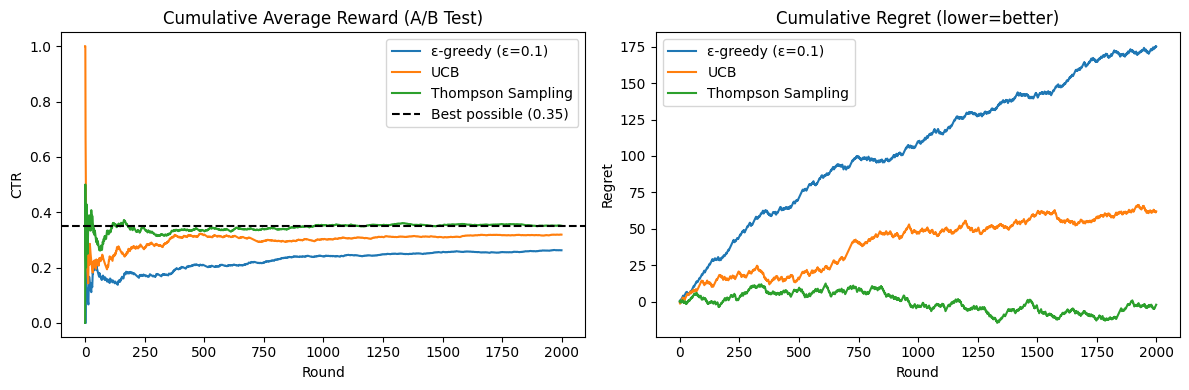


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [5]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
# Save a value in a name so the next lines can read it.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
# Another assignment—same idea: store a value for the lines below.
N_ARMS   = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 2000

# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        arm = np.random.randint(N_ARMS) if np.random.rand()<eps else np.argmax(totals/(counts+1e-9))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for arm in range(N_ARMS): r=pull(arm); counts[arm]=1; totals[arm]+=r; rewards.append(r)
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ARMS, N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        ucb_vals = totals/counts + np.sqrt(2*np.log(t+1)/counts)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(ucb_vals)
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Save a value in a name so the next lines can read it.
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        samples = np.random.beta(alpha, beta_)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(samples)
        # Another assignment—same idea: store a value for the lines below.
        r = pull(arm)
        # If the condition is True, run the indented block under this line.
        if r: alpha[arm]+=1
        # Else: run this block when none of the if/elif tests above matched.
        else: beta_[arm]+=1
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Save a value in a name so the next lines can read it.
strategies = {
    # Another assignment—same idea: store a value for the lines below.
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'UCB':               ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'Thompson Sampling': thompson(),
# Part of a dict/set literal layout (syntax grouping).
}

# Function `cumavg` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def cumavg(lst): return np.cumsum(lst) / np.arange(1,len(lst)+1)

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(12,4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,1)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumavg(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(max(TRUE_RATES), color='k', linestyle='--', label=f"Best possible ({max(TRUE_RATES)})")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Average Reward (A/B Test)"); plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,2)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Regret so far = reward the best arm would have paid, minus the reward actually collected.
    regret_simple = np.cumsum(max(TRUE_RATES) - np.array(r))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(regret_simple, label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Regret (lower=better)"); plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()
# Show text or numbers in the cell output area under the code.
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")


### 👁️ Read the figure

- **Left, average reward per round.** The dashed line at **0.35** is what always picking
  variant 3 would earn. Thompson Sampling reaches it, UCB ends just under it, ε-greedy
  flattens around 0.26 and stays there.
- **Right, cumulative regret — down is good.** ε-greedy's line is *straight*: it keeps losing
  reward at a constant rate, so round 20,000 would look no better than round 2,000. UCB bends
  over near 60. Thompson hugs zero.
- **The totals under the figure are the same story in one number:** 525 conversions for
  ε-greedy, 638 for UCB, **702 for Thompson Sampling** on the identical five variants and the
  identical 2,000 visitors.
- **Honest caveat:** regret is measured here against the *realised* 0/1 conversions, so luck
  can push the green curve a little below zero. Expected regret cannot be negative.

**What it proves:** all three strategies saw the same traffic. The only thing that differed
was how they decided what to show next, and that alone was worth ~180 extra conversions.

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Lattimore, T. & Szepesvári, C. (2020). *Bandit Algorithms*. Cambridge University Press.
4. Ecoffet, A., Huizinga, J., Lehman, J., Stanley, K. O. & Clune, J. (2021). *First Return, Then Explore* (Go-Explore). Nature. <https://www.nature.com/articles/s41586-020-03157-9>
5. Anand, E. & Liaw, S. (2025). *Feel-Good Thompson Sampling for Contextual Bandits: a Markov Chain Monte Carlo Showdown*. arXiv:2507.15290. <https://arxiv.org/abs/2507.15290> — a 2025 study of Thompson-sampling variants under exact and approximate posteriors; the authors recommend them as baselines in modern contextual-bandit benchmarks.
6. Cui, G., Zhang, Y., Chen, J., Yuan, L. et al. (2025). *The Entropy Mechanism of Reinforcement Learning for Reasoning Language Models*. arXiv:2505.22617. <https://arxiv.org/abs/2505.22617> — this lesson's temperature knob at language-model scale: policy entropy drops sharply early in training and takes exploratory ability with it.
"""))

## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Lattimore, T. & Szepesvári, C. (2020). *Bandit Algorithms*. Cambridge University Press.
4. Ecoffet, A., Huizinga, J., Lehman, J., Stanley, K. O. & Clune, J. (2021). *First Return, Then Explore* (Go-Explore). Nature. <https://www.nature.com/articles/s41586-020-03157-9>
5. Anand, E. & Liaw, S. (2025). *Feel-Good Thompson Sampling for Contextual Bandits: a Markov Chain Monte Carlo Showdown*. arXiv:2507.15290. <https://arxiv.org/abs/2507.15290> — a 2025 study of Thompson-sampling variants under exact and approximate posteriors; the authors recommend them as baselines in modern contextual-bandit benchmarks.
6. Cui, G., Zhang, Y., Chen, J., Yuan, L. et al. (2025). *The Entropy Mechanism of Reinforcement Learning for Reasoning Language Models*. arXiv:2505.22617. <https://arxiv.org/abs/2505.22617> — this lesson's temperature knob at language-model scale: policy entropy drops sharply early in training and takes exploratory ability with it.


## 💬 Discuss

The measured results. Thompson posteriors against truth: arm 0 **0.409** (true 0.35), arm 1
**0.540** (true 0.55), arm 2 **0.278** (true 0.40). The A/B application after 2000 visitors: design A
**0.089** (true 0.08), design B **0.113** (true 0.11). Boltzmann over 400 rounds: hot τ=5.0 scored
**180**, cool τ=0.2 scored **181** — a tie. Argue these out.

1. Arm 2's posterior mean (0.278) is well below its true value (0.40), while arm 0's (0.409) is well
   above its true 0.35. Both errors are *large*. Why is the algorithm nevertheless doing its job? What
   would you have to see in the posteriors before you called this a failure?
2. The Boltzmann comparison ended 180 to 181 and the notebook says outright that 400 rounds cannot
   separate them. A manager reads "cool temperature won" from that table. Write the correction — and
   then write what you would actually do to answer the question properly.
3. Thompson's 1933 motivation was allocating patients between treatments. A hospital in the Gulf asks
   you to use Thompson sampling to allocate patients to two care pathways, arguing it is more ethical
   than randomising 50/50 because fewer patients get the worse arm. Give the strongest argument for,
   the strongest argument against, and say which side you would take in the ethics committee.


## 📝 Summary

You compared **exploration strategies**: ε-greedy (simple, effective), UCB (optimism under uncertainty), and Thompson Sampling (Bayesian). You also implemented **Boltzmann (softmax) exploration**, where a temperature τ turns value estimates into action probabilities — and saw that cooling τ over time plays the same role as an ε-decay schedule. The exploration-exploitation tradeoff is central to RL. Real applications: A/B testing at Netflix, ad bidding at Google, recommendation engines at Spotify.

### Step Guide

**What this cell does:** Draws the closing figure — the two *distributions* this lesson built: Thompson Sampling's Beta posterior per arm, and the Boltzmann action probabilities at four temperatures.

**How to read it (weak Python OK):** Nothing new is learned here. The cell reads `ts` (trained in Part 1) and `q_estimates` / `boltzmann_probs` (Part 3) and draws them.

**What to expect in the output:** One figure with two panels — three posterior curves on the left, a grouped bar chart of action probabilities on the right — plus a short printed table.

**If you feel lost:** Re-run the Part 1 and Part 3 cells above so `ts` and `boltzmann_probs` exist, then run this cell again.

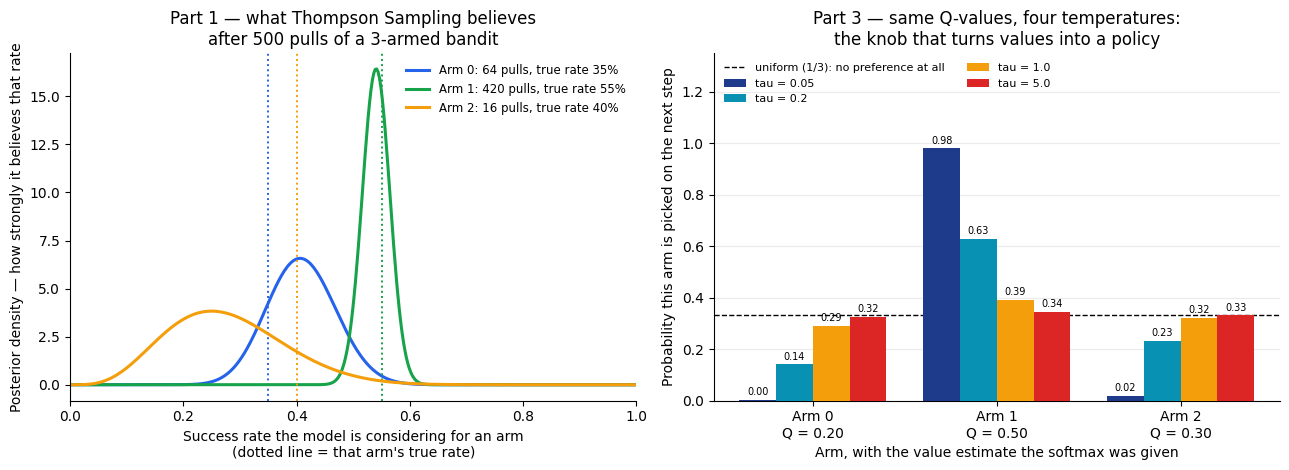

Posterior mean per arm (left panel), after 500 pulls:
  Arm 0: 0.409  (true 0.35, pulled 64 times)
  Arm 1: 0.540  (true 0.55, pulled 420 times)
  Arm 2: 0.278  (true 0.40, pulled 16 times)

P(pick arm 1, the highest-Q arm) as temperature rises (right panel):
  tau = 0.05  -> 0.980
  tau = 0.2   -> 0.629
  tau = 1.0   -> 0.391
  tau = 5.0   -> 0.345


In [7]:
# Closing figure: both halves of this lesson are DISTRIBUTIONS, not single numbers.
# Left  — what Thompson Sampling believes about each arm after 500 pulls (Part 1).
# Right — how one temperature knob turns fixed value estimates into a policy (Part 3).
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

fig, (ax_post, ax_soft) = plt.subplots(1, 2, figsize=(13, 4.8))

# ---------- Left panel: the Beta posterior of each arm ----------
grid = np.linspace(0.0, 1.0, 400)          # every success rate the model could believe in
arm_colors = ["#2563eb", "#16a34a", "#f59e0b"]
for i, color in enumerate(arm_colors):
    a, b = ts.alpha[i], ts.beta[i]
    n_pulls = int(a + b - 2)               # Beta(1,1) prior means alpha+beta starts at 2
    ax_post.plot(grid, beta_dist.pdf(grid, a, b), color=color, lw=2.2,
                 label=f"Arm {i}: {n_pulls} pulls, true rate {arm_success_rates[i]:.0%}")
    # Dotted vertical line = the arm's TRUE success rate, which the model never sees.
    ax_post.axvline(arm_success_rates[i], color=color, ls=":", lw=1.4)

ax_post.set_xlim(0.0, 1.0)
ax_post.set_xlabel("Success rate the model is considering for an arm\n(dotted line = that arm's true rate)")
ax_post.set_ylabel("Posterior density — how strongly it believes that rate")
ax_post.set_title("Part 1 — what Thompson Sampling believes\nafter 500 pulls of a 3-armed bandit")
ax_post.legend(fontsize=8.5, frameon=False)
ax_post.spines[["top", "right"]].set_visible(False)

# ---------- Right panel: Boltzmann probabilities at four temperatures ----------
taus = [0.05, 0.2, 1.0, 5.0]
tau_colors = ["#1e3a8a", "#0891b2", "#f59e0b", "#dc2626"]   # cool -> hot
x = np.arange(len(q_estimates))            # three arms: categories, so bars and never a line
bar_width = 0.2

for k, (tau, color) in enumerate(zip(taus, tau_colors)):
    probs = boltzmann_probs(q_estimates, tau)
    bars = ax_soft.bar(x + (k - 1.5) * bar_width, probs, bar_width,
                       color=color, label=f"tau = {tau}", zorder=3)
    ax_soft.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)

# Reference line: what "explore blindly" would look like with 3 arms.
ax_soft.axhline(1 / len(q_estimates), color="black", ls="--", lw=1,
                label="uniform (1/3): no preference at all", zorder=2)
ax_soft.set_xticks(x)
ax_soft.set_xticklabels([f"Arm {i}\nQ = {q:.2f}" for i, q in enumerate(q_estimates)])
ax_soft.set_xlabel("Arm, with the value estimate the softmax was given")
ax_soft.set_ylabel("Probability this arm is picked on the next step")
ax_soft.set_title("Part 3 — same Q-values, four temperatures:\nthe knob that turns values into a policy")
ax_soft.set_ylim(0.0, 1.35)          # headroom so the legend never sits on a bar
ax_soft.legend(fontsize=8, frameon=False, ncol=2, loc="upper left")
ax_soft.spines[["top", "right"]].set_visible(False)
ax_soft.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
plt.show()

# The same two panels as numbers, for quoting in notes.
print("Posterior mean per arm (left panel), after 500 pulls:")
for i in range(len(arm_success_rates)):
    a, b = ts.alpha[i], ts.beta[i]
    print(f"  Arm {i}: {a / (a + b):.3f}  (true {arm_success_rates[i]:.2f}, pulled {int(a + b - 2)} times)")
print("\nP(pick arm 1, the highest-Q arm) as temperature rises (right panel):")
for tau in taus:
    print(f"  tau = {tau:<5} -> {boltzmann_probs(q_estimates, tau)[1]:.3f}")


### 👁️ Read the figure

**Left — the belief, not the estimate.** Three Beta posteriors after 500 pulls. Each dotted
vertical line is that arm's *true* rate, which the agent never sees.
- **Green (arm 1, true 55%) is tall and narrow** because it collected **420 of the 500 pulls**.
  Its posterior mean is **0.540** and the curve is only about 0.1 wide — that is what
  "confident" looks like.
- **Blue (arm 0, true 35%) is short and wide** — 64 pulls, posterior mean **0.409**. The
  model *overestimates* it and knows it might be wrong; the curve still covers 0.30–0.55.
- **Orange (arm 2, true 40%) is the flattest and it is wrong**: 16 pulls, posterior mean
  **0.278** against a true 40%. Thompson Sampling gave up on it early and never came back.

That last point is the honest part. Thompson Sampling does **not** learn every arm accurately;
it spends its pulls where a mistake would be expensive. Arm 2 stays badly estimated forever
here, and that costs nothing — it is not the best arm.

**Right — the temperature knob.** The same three Q-values (0.20, 0.50, 0.30) every time; only
τ changes. P(pick arm 1, the highest-Q arm) falls **0.98 → 0.63 → 0.39 → 0.34** as τ goes
0.05 → 0.2 → 1.0 → 5.0, and at τ = 5.0 all three bars sit on the dashed uniform line (1/3):
the Q-values have stopped mattering at all. Bars, not a line — arms 0, 1, 2 are three separate
choices, not three points on a curve.

**What it proves:** "exploration" is a *shape*. Thompson explores by drawing from a
distribution it keeps updating; Boltzmann explores by flattening one it computes on demand.
Both replace a hard argmax with a distribution — that is the whole idea of this lesson.

## ⚠️ Where this breaks

**The assumption that has to hold:** your prior and likelihood are roughly right, and the arms are
independent and stationary.

- **Beta-Bernoulli assumes binary, independent rewards.** The code below models each arm as a coin
  with an unknown bias. Real payoffs are often continuous (revenue per visitor), heavy-tailed (one
  customer worth 100 others) or correlated between arms (two thumbnails from the same show). Applying
  the Beta update anyway does not produce an error message — it produces confident wrong posteriors.
- **The prior matters when data is scarce, which is exactly when you are using this.** A confident
  wrong prior can suppress an arm long enough that it never accumulates the evidence to recover.
- **Non-stationarity is invisible to it.** Posteriors sharpen monotonically: the more data, the more
  certain, forever. If arm values drift, Thompson sampling becomes *more* confident about a world that
  no longer exists. Discounting or sliding windows are the usual repairs, and both add a parameter.
- **Boltzmann's temperature is a raw hyperparameter on an unbounded scale.** The τ table below shows
  the same Q-values producing anything from near-greedy (τ=0.05) to near-uniform (τ=5.0). Unlike ε,
  τ interacts with the *scale* of your rewards — rescale the reward and your carefully tuned τ means
  something else.
- **Cheaper alternative:** with two arms, plenty of traffic and a single decision to make, a
  classical fixed-horizon A/B test gives you a p-value, a confidence interval and a procedure a
  regulator recognises. Thompson sampling gives you more total reward and a much harder conversation
  about what exactly was tested.


## Closing Takeaway

**Teaching takeaway:** Good RL systems do not maximize exploration forever or exploit too early; they manage the balance as learning evolves.

**If students remember one idea:** The right balance depends on uncertainty, risk, and how costly mistakes are in the environment.

**Quick check before moving on:**
- Can you explain what goes wrong when exploitation starts too early?
- Can you describe why continued exploration may still matter even after performance improves?

**Bridge to the next step:** This sets up adaptive methods like UCB, which adjust exploration using information gathered so far.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

Softmax action selection stopped being a bandit-only device. It is the sampling distribution of every
language model, and the temperature τ you cool below is that model's temperature — which is why
exploration control became the live problem in reinforcement learning for reasoning models. Cui et al.
report that policy entropy drops sharply early in RL training, that the diminished exploratory ability
arrives together with a plateau in performance, and that restricting updates on high-covariance tokens
(their Clip-Cov and KL-Cov) keeps entropy, and therefore exploration, alive (arXiv:2505.22617, 2025).
On the bandit side nothing was superseded: a 2025 comparison of Feel-Good Thompson-sampling variants
under exact and approximate posteriors concludes they are competitive, easy to use, and should serve as
baselines in modern contextual-bandit benchmarks (Anand & Liaw, arXiv:2507.15290, 2025). So learn the
two mechanisms exactly as this lesson teaches them: the Beta posterior is the baseline a new contextual-
bandit method still has to beat, the temperature is the knob the 2026 training literature is arguing
over, and 400 rounds of a three-armed bandit is the smallest place where you can watch either one move.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=10 | term=True | trunc=False


objc[59626]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x115cd8138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11634c9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59626]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x115cd8188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11634ca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59626]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x115cd7c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11634ca68). T

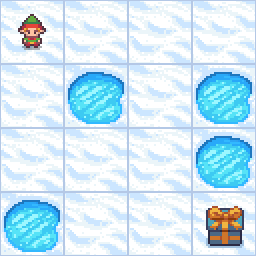

In [8]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
